# Import, set up plt dynamics, and define functions

In [302]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [303]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

In [304]:
def nc_func(t, sharpness, min_val=1, max_val=6, lockdown_start=7):
    """
    Calculate contact rate nc with exponential decay after lockdown_start.

    Args:
        t: Current time
        sharpness: Negative value controlling decay speed (more negative = faster lockdown)
        min_val: Minimum contact rate (lockdown strength)
        max_val: Maximum contact rate (normal activity)
        lockdown_start: Fixed time when lockdown begins (default=5)

    Returns:
        Contact rate between min_val and max_val
    """
    t0 = max(t - lockdown_start, 0)  # Time since lockdown started
    decay = np.exp(sharpness * t0)  # Exponential decay factor
    return min_val + (max_val - min_val) * decay  # Always between min_val and max_val

In [305]:
def seird(t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=None):
    """
    Calculate contact population dynamics rate changes at time t when given the input to a SEIRD model

    Args:
        t: Current time
        X: Population at time t
        pt: Transmission rate (higher means more infections)
        b: Recovery rate, the rate at which infected indviduals become recovered individuals
        c: The vacination rate, the rate at which susceptible individuals become recovered individuals
        eta: The death rate, the rate at which infected individuals become deceased individuals
        gamma: The rate at which recovered individuals become susceptible individuals
        nu: The rate at which exposed individuals become infected individuals
        N: Total population
        lockdown: Whether or not to apply lockdown
        sharpness: Negative value controlling decay speed (more negative = faster lockdown)

    Returns:
        Population dyamics rates for SEIRD model
    """
    if lockdown:
        nc_val = nc_func(t, sharpness)
    else:
        nc_val = 6

    a = pt * nc_val
    s, e, i, r, d = X
    ds = -a * s * i / N - c * s + gamma * r
    de = a * s * i / N - nu * e
    di = nu * e - b * i - eta * i
    dr = b * i + c * s - gamma * r
    dd = eta * i
    return [ds, de, di, dr, dd]

# Run SEIRD Scenarios without Lockdown and with Lockdown (s=-0.1) for 120 Days

In [306]:
# Parameters

# Parameters

Number_of_days = 120
Time_step = 0.1

# Time span for simulation is 120 days or roughly 4 months
tspan = (0, Number_of_days)
t_eval = np.arange(0, 120, Time_step)

# Population size
N = 2e6

# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1

# research found ranges from 0.03 to 0.06
# Recovery rate, the rate at which infected individuals become recovered.
b = 0.05

# The vacination rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)

# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
# Eta from death rate and recovery rate
eta = DEATH_RATE * b / (1 - DEATH_RATE)

# The mutation rate, the rate at which recovered individuals becmome susceptible individual
gamma = 0.008

nu = 0.22

# Initial Population Dynamic array, [S, E, I, R, D]
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]

# Adjust this value to control lockdown sharpness
sharpness = -0.1

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T, X = sol.t, sol.y

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

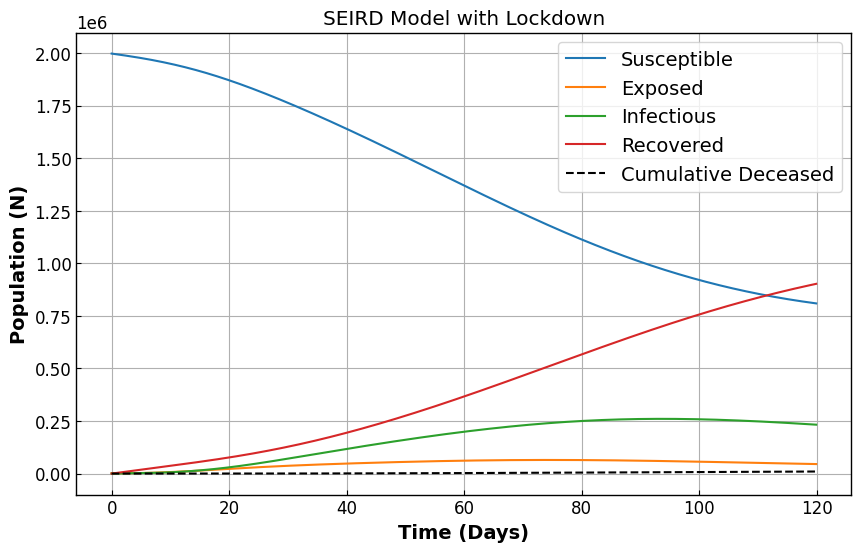

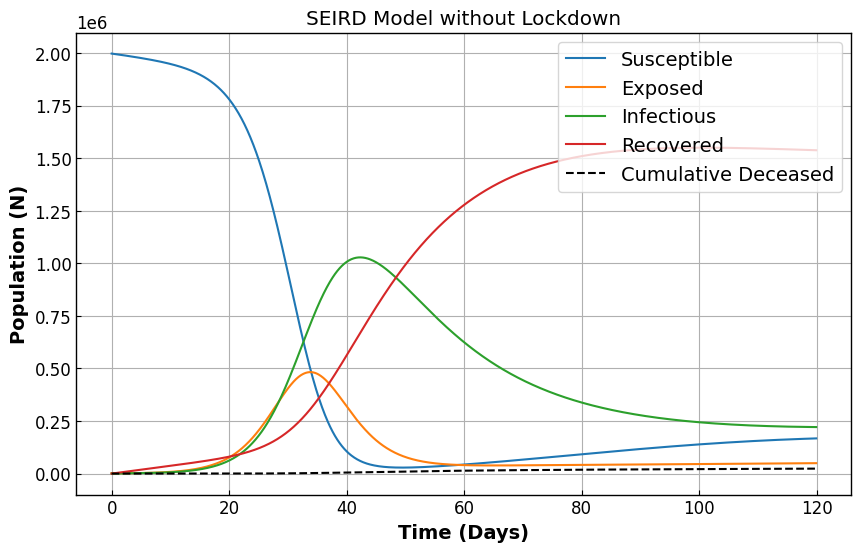

In [307]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(5):

    if i == 4:
        plt.plot(T_lock, X_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_lock, X_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(5):

    if i == 4:
        plt.plot(T, X[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T, X[i], label=labels[i])
plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model without Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

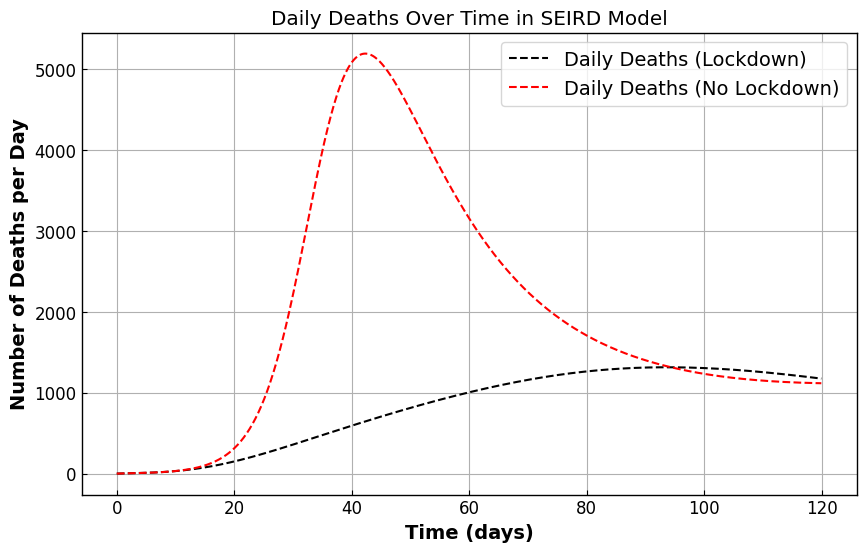

In [308]:
dt = t_eval[1] - t_eval[0]  # 0.1 days

daily_deaths = eta * X_lock[2] / dt
daily_deaths_no_lockdown = eta * X[2] / dt

plt.figure(figsize=(10, 6))
plt.plot(
    T_lock, daily_deaths, label="Daily Deaths (Lockdown)", color="black", linestyle="--"
)
plt.plot(
    T,
    daily_deaths_no_lockdown,
    label="Daily Deaths (No Lockdown)",
    color="red",
    linestyle="--",
)
plt.xlabel("Time (days)")
plt.ylabel("Number of Deaths per Day")
plt.title("Daily Deaths Over Time in SEIRD Model")
plt.legend()
plt.grid(True)
plt.show()

# Run Productivity Analysis with Lockdown (s=-0.1 and s=-.04) and Without Lockdown for 120 Days

In [309]:
# Parameters

Number_of_days = 120
Time_step = 0.1

# Time span for simulation is 120 days or roughly 4 months
tspan = (0, Number_of_days)
t_eval = np.arange(0, Number_of_days, Time_step)

# Population size
N = 2e6

# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1

# research found ranges from 0.03 to 0.06
# Recovery rate, the rate at which infected individuals become recovered.
b = 0.05

# The vacination rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)

# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
# Eta from death rate and recovery rate
eta = DEATH_RATE * b / (1 - DEATH_RATE)

# The mutation rate, the rate at which recovered individuals becmome susceptible individual
gamma = 0.008

nu = 0.22

# Initial Population Dynamic array, [S, E, I, R, D]
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]


# Parameters for Judging Productivity
hevNoLockdown = 1 # Productivity of average individual with no lockdown
hevLockdown = .9 # Productivity of average individual with a lockdown
sevLockdown = .9 # Productivity of susceptible individual with a lockdown
eev = .8 # Productivity of an exposed individual
iev = -.25 # Productivity of an infected individual
d = 0 # Productivity of a deceased individual

# SCENARIO 1, Lockdown with sharpness -0.1
# S, E, I, R, D
X0  = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

# SCENARIO 2, no Lockdown
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_no_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_no_lock, X_no_lock = sol_no_lock.t, sol_no_lock.y

# SCENARIO 3, Lockdown with sharpness -0.04
# S, E, I, R, D
X0  = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness=-0.04

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_Slow_lock, X_Slow_lock = sol_lock.t, sol_lock.y

In [310]:
# Initialize Arrays
productivity_no_lockdown = np.zeros(int(Number_of_days/Time_step))
productivity_lockdown = np.zeros(int(Number_of_days/Time_step))
productivity_slow_lockdown = np.zeros(int(Number_of_days/Time_step))

# Variable to track quarentine days
lockdown_time=0

# Run through all time points and sum the productivity arrays
for x in range(int(Number_of_days/Time_step)):

  #Productivity of no lockdown model
  productivity_no_lockdown[x] = hevNoLockdown * (X[0][x] + X[3][x]) + iev * X[2][x] + eev * X[1][x]

  # If there are infected individuals, the lockdown continues.  Sum productivities of slow lockdown and fast lockdown
  if X_lock[2][x] >= 1:
    productivity_lockdown[x] = hevLockdown * X_lock[0][x]  + iev * X_lock[2][x] + eev * X_lock[1][x] + X_lock[3][x]
    productivity_slow_lockdown[x] = hevLockdown * X_Slow_lock[0][x]  + iev * X_Slow_lock[2][x] + eev * X_Slow_lock[1][x]+ X_Slow_lock[3][x]

  # If there are no infected individuals, the quarantine timer starts.
  elif lockdown_time <140:
    productivity_lockdown[x] = hevLockdown * X_lock[0][x]  + iev * X_lock[2][x] + eev * X_lock[1][x] + X_lock[3][x]
    productivity_slow_lockdown[x] = hevLockdown * X_Slow_lock[0][x]  + iev * X_Slow_lock[2][x] + eev * X_Slow_lock[1][x]+ X_Slow_lock[3][x]
    lockdown_time+=1

  # Once the quarantine timer expires, the population can leave lockdown
  else:
    productivity_lockdown[x] = (hevNoLockdown * (X_lock[0][x] + X_lock[3][x])  + iev * X[2][x] + eev * X[1][x])
    productivity_slow_lockdown[x] = (hevNoLockdown * (X_Slow_lock[0][x] + X_Slow_lock[3][x])  + iev * X[2][x] + eev * X[1][x])

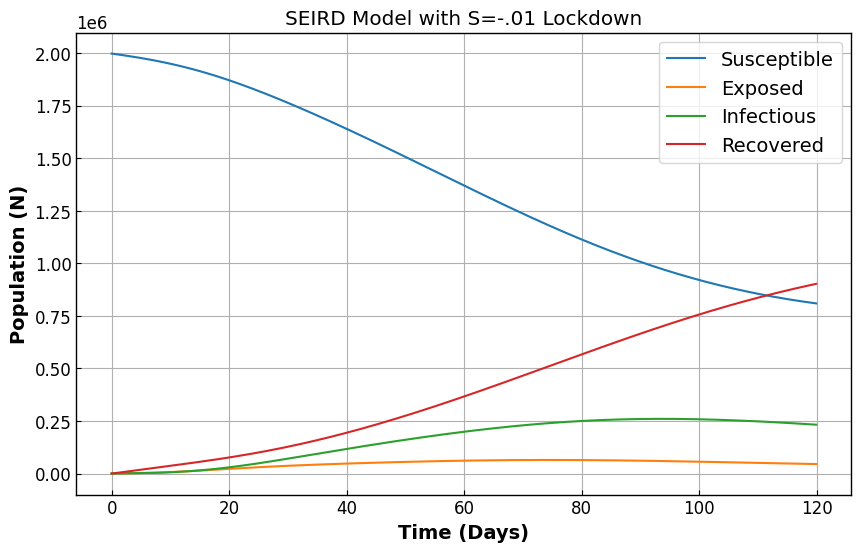

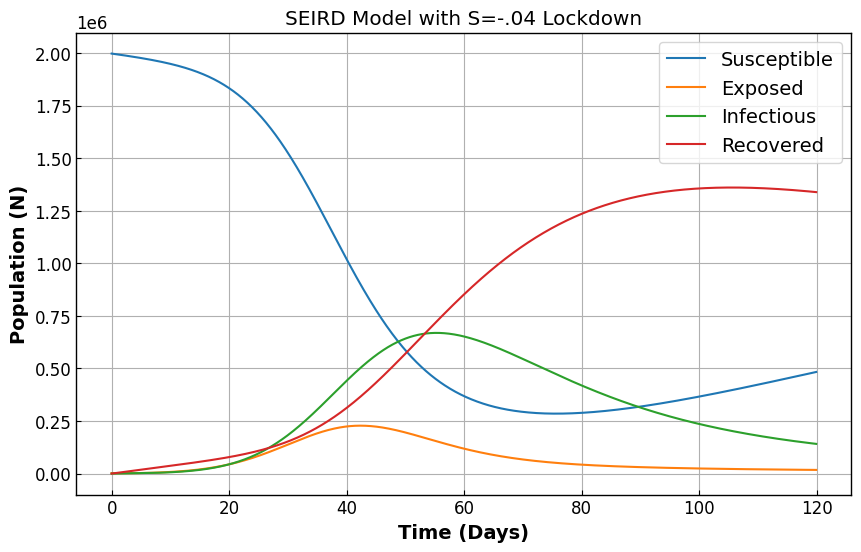

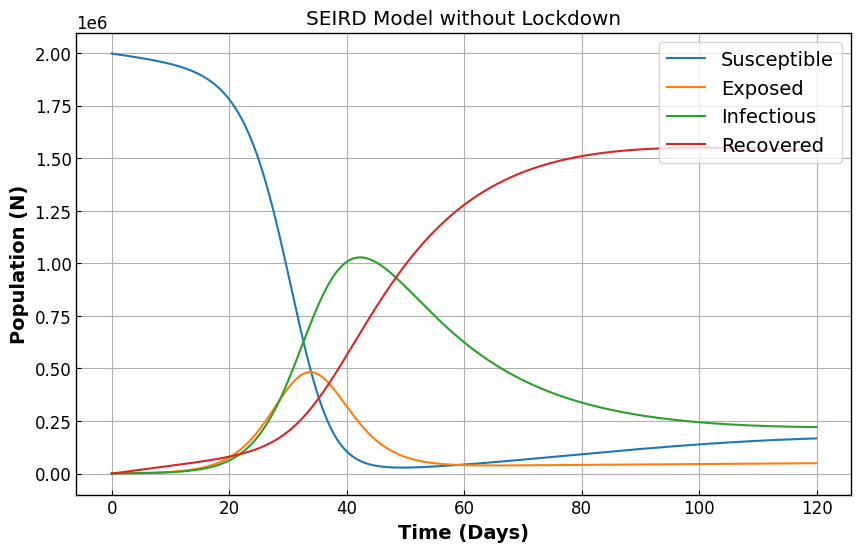

In [311]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_lock, X_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_lock, X_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with S=-.01 Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_Slow_lock, X_Slow_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_Slow_lock, X_Slow_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with S=-.04 Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_no_lock, X_no_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_no_lock, X_no_lock[i], label=labels[i])
plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model without Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

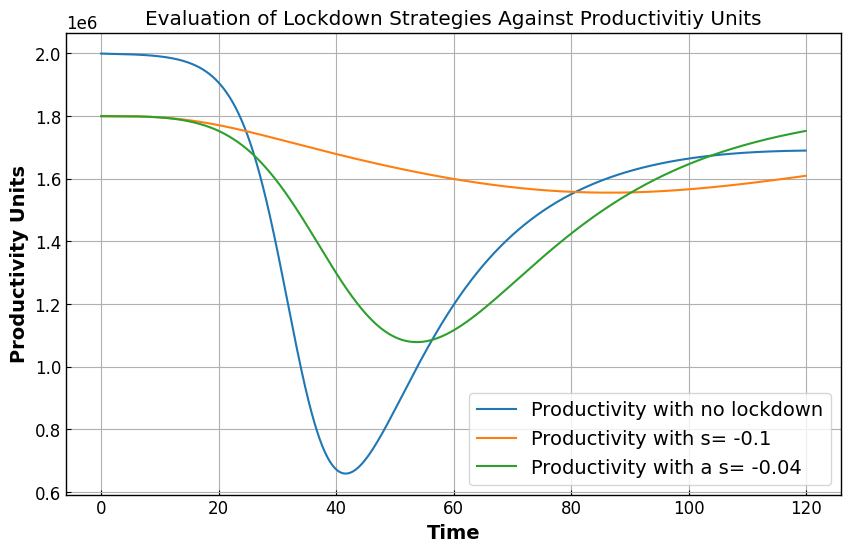

In [312]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(T_no_lock, productivity_no_lockdown, label ="Productivity with no lockdown")
plt.plot(T_lock, productivity_lockdown, label ="Productivity with s= -0.1")
plt.plot(T_Slow_lock, productivity_slow_lockdown, label ="Productivity with a s= -0.04")
plt.xlabel("Time")
plt.ylabel("Productivity Units")
plt.title("Evaluation of Lockdown Strategies Against Productivitiy Units")
plt.legend()
plt.grid(True)
plt.show()

# Run Productivity Analysis with Lockdown (s=-0.1 and s=-.04) and Without Lockdown for 365 Days

In [313]:
Number_of_days = 365
Time_step = 0.1

# Time span for simulation is 120 days or roughly 4 months
tspan = (0, Number_of_days)
t_eval = np.arange(0, Number_of_days, Time_step)

# Population size
N = 2e6

# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1

# research found ranges from 0.03 to 0.06
# Recovery rate, the rate at which infected individuals become recovered.
b = 0.05

# The vacination rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)

# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
# Eta from death rate and recovery rate
eta = DEATH_RATE * b / (1 - DEATH_RATE)

# The mutation rate, the rate at which recovered individuals becmome susceptible individual
gamma = 0.008

nu = 0.22

# Initial Population Dynamic array, [S, E, I, R, D]
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]


# Parameters for Judging Productivity
hevNoLockdown = 1 # Productivity of average individual with no lockdown
hevLockdown = .9 # Productivity of average individual with a lockdown
sevLockdown = .9 # Productivity of susceptible individual with a lockdown
eev = .8 # Productivity of an exposed individual
iev = -.25 # Productivity of an infected individual
d = 0 # Productivity of a deceased individual

# SCENARIO 1, Lockdown with sharpness -0.1
# S, E, I, R, D
X0  = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

# SCENARIO 2, no Lockdown
# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_no_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_no_lock, X_no_lock = sol_no_lock.t, sol_no_lock.y

# SCENARIO 3, Lockdown with sharpness -0.04
# S, E, I, R, D
X0  = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness=-0.04

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_Slow_lock, X_Slow_lock = sol_lock.t, sol_lock.y

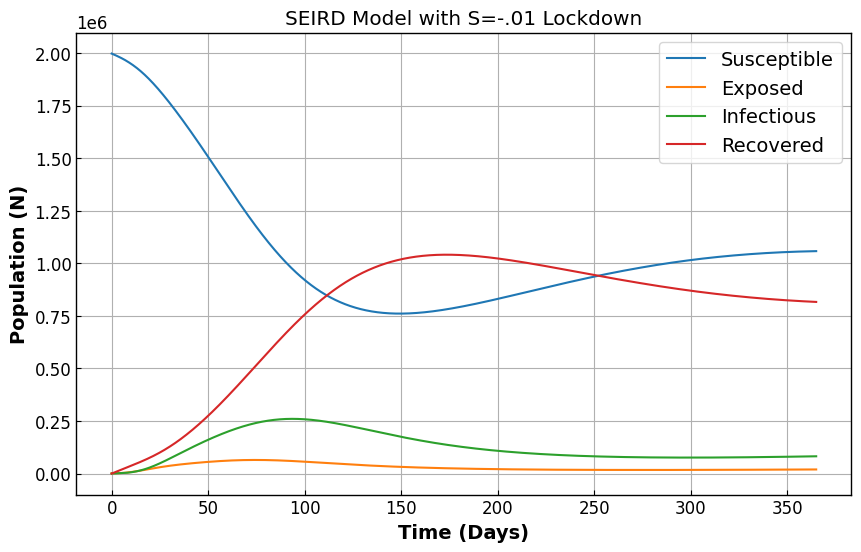

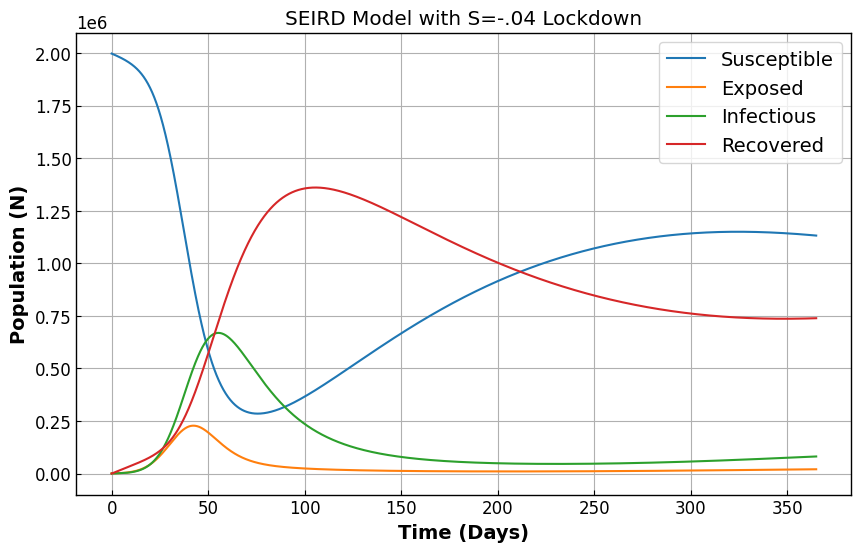

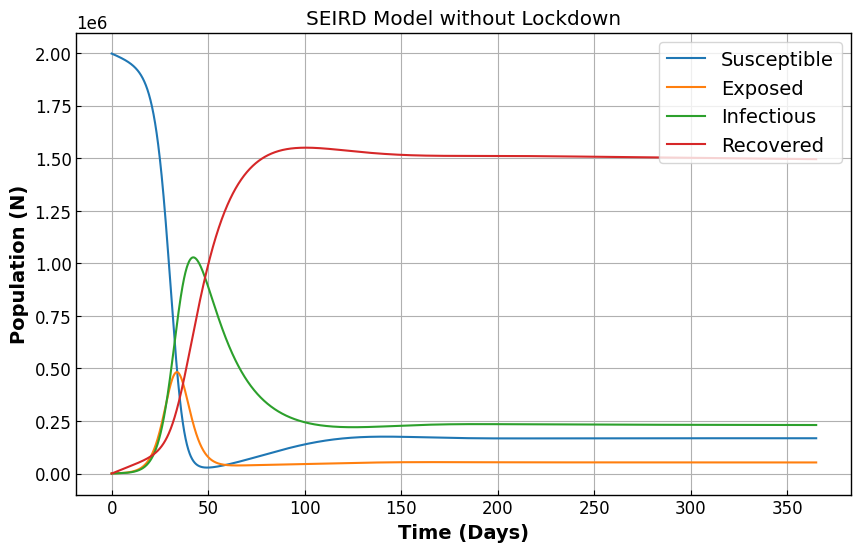

In [314]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_lock, X_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_lock, X_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with S=-.01 Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_Slow_lock, X_Slow_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_Slow_lock, X_Slow_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with S=-.04 Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_no_lock, X_no_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_no_lock, X_no_lock[i], label=labels[i])
plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model without Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

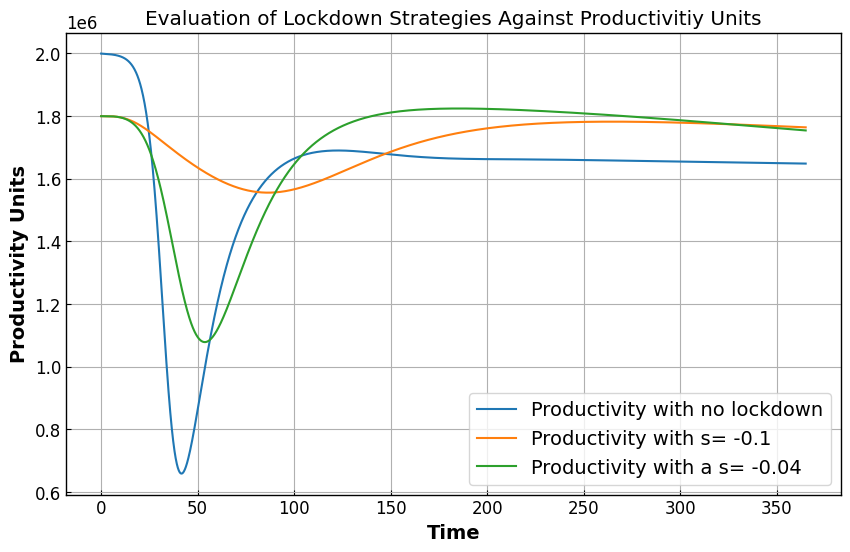

In [315]:
# Initialize Arrays
productivity_no_lockdown = np.zeros(int(Number_of_days/Time_step))
productivity_lockdown = np.zeros(int(Number_of_days/Time_step))
productivity_slow_lockdown = np.zeros(int(Number_of_days/Time_step))

# Variable to track quarentine days
lockdown_time=0

# Run through all time points and sum the productivity arrays
for x in range(int(Number_of_days/Time_step)):

  #Productivity of no lockdown model
  productivity_no_lockdown[x] = hevNoLockdown * (X_no_lock[0][x] + X_no_lock[3][x]) + iev * X_no_lock[2][x] + eev * X_no_lock[1][x]

  # If there are infected individuals, the lockdown continues.  Sum productivities of slow lockdown and fast lockdown
  if X_lock[2][x] >= 1:
    productivity_lockdown[x] = hevLockdown * X_lock[0][x]  + iev * X_lock[2][x] + eev * X_lock[1][x] + X_lock[3][x]
    productivity_slow_lockdown[x] = hevLockdown * X_Slow_lock[0][x]  + iev * X_Slow_lock[2][x] + eev * X_Slow_lock[1][x]+ X_Slow_lock[3][x]

  # If there are no infected individuals, the quarantine timer starts.
  elif lockdown_time <140:
    productivity_lockdown[x] = hevLockdown * X_lock[0][x]  + iev * X_lock[2][x] + eev * X_lock[1][x] + X_lock[3][x]
    productivity_slow_lockdown[x] = hevLockdown * X_Slow_lock[0][x]  + iev * X_Slow_lock[2][x] + eev * X_Slow_lock[1][x]+ X_Slow_lock[3][x]
    lockdown_time+=1

  # Once the quarantine timer expires, the population can leave lockdown
  else:
    productivity_lockdown[x] = (hevNoLockdown * (X_lock[0][x] + X_lock[3][x])  + iev * X[2][x] + eev * X[1][x])
    productivity_slow_lockdown[x] = (hevNoLockdown * (X_Slow_lock[0][x] + X_Slow_lock[3][x])  + iev * X[2][x] + eev * X[1][x])

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(T_lock, productivity_no_lockdown, label ="Productivity with no lockdown")
plt.plot(T_lock, productivity_lockdown, label ="Productivity with s= -0.1")
plt.plot(T_lock, productivity_slow_lockdown, label ="Productivity with a s= -0.04")
plt.xlabel("Time")
plt.ylabel("Productivity Units")
plt.title("Evaluation of Lockdown Strategies Against Productivitiy Units")
plt.legend()
plt.grid(True)
plt.show()

# Run SEIRD Models for 1000 Days

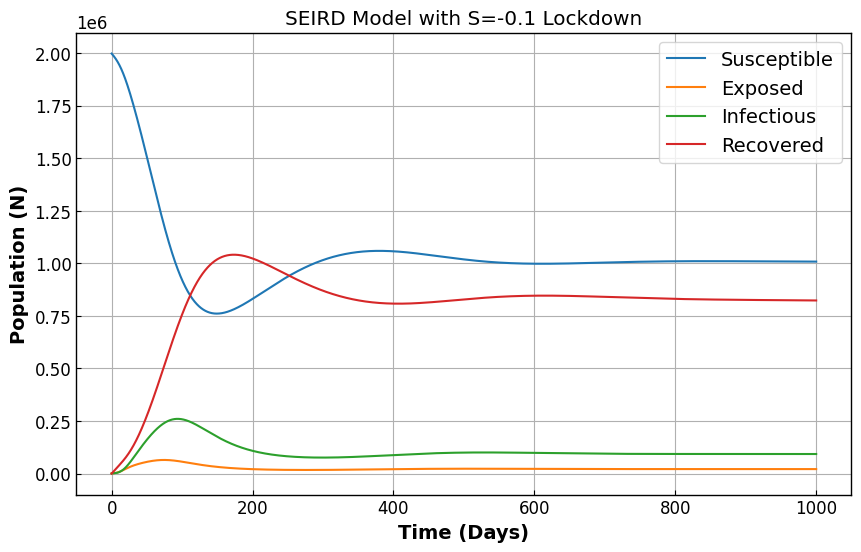

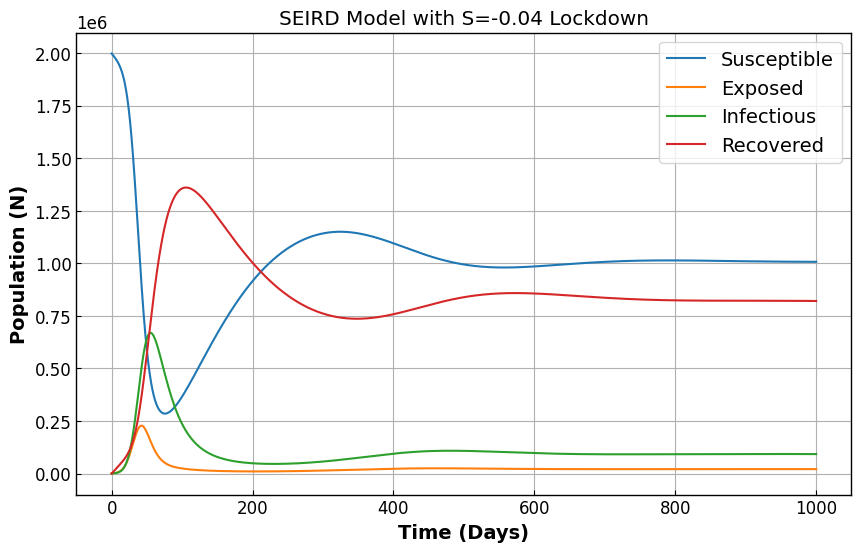

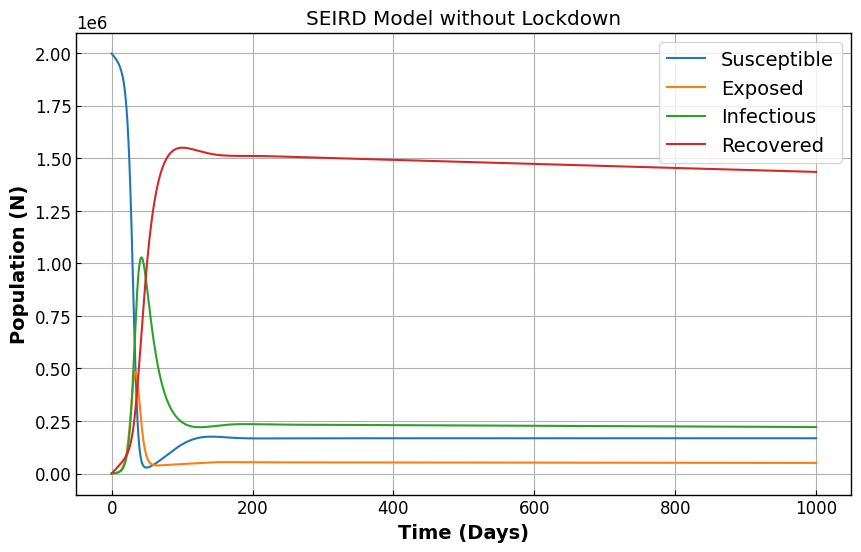

In [316]:
Number_of_days = 1000
Time_step = 0.1

# Time span for simulation is 120 days or roughly 4 months
tspan = (0, Number_of_days)
t_eval = np.arange(0, Number_of_days, Time_step)


# S, E, I, R, D
X0  = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

# S, E, I, R, D
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_no_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_no_lock, X_no_lock = sol_no_lock.t, sol_no_lock.y


# S, E, I, R, D
X0  = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness=-0.04

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_Slow_lock, X_Slow_lock = sol_lock.t, sol_lock.y

fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_lock, X_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_lock, X_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with S=-0.1 Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_Slow_lock, X_Slow_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_Slow_lock, X_Slow_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with S=-0.04 Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_no_lock, X_no_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_no_lock, X_no_lock[i], label=labels[i])
plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model without Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()